load data


In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv("adult.csv")

WE WILL DO DATA CLEANING FIRST

In [29]:
df.isna().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [30]:
df.nunique()

age                   74
workclass              9
fnlwgt             28523
education             16
educational-num       16
marital-status         7
occupation            15
relationship           6
race                   5
gender                 2
capital-gain         123
capital-loss          99
hours-per-week        96
native-country        42
income                 2
dtype: int64

In [31]:
#unique values counts


print(df.value_counts())

age  workclass         fnlwgt  education    educational-num  marital-status      occupation         relationship   race                gender  capital-gain  capital-loss  hours-per-week  native-country  income
25   Private           308144  Bachelors    13               Never-married       Craft-repair       Not-in-family  White               Male    0             0             40              Mexico          <=50K     3
21   Private           243368  Preschool    1                Never-married       Farming-fishing    Not-in-family  White               Male    0             0             50              Mexico          <=50K     3
25   Private           195994  1st-4th      2                Never-married       Priv-house-serv    Not-in-family  White               Female  0             0             40              Guatemala       <=50K     3
31   Private           228873  HS-grad      9                Married-civ-spouse  Craft-repair       Husband        White               Male    0 

In [32]:
print("standard missing values")
print(df.isnull().sum())

select_categorical_only = df.select_dtypes(include = "object").columns # columns lagane sirf columns ko lerhe uske andr ke data nhi
print(select_categorical_only)
for col in select_categorical_only:
    print(f"\n{col}")
    print(f"The unique values from {col}  are: {df[col].unique()}")
    print("total unique values are:  ")
    print(df[col].nunique())



standard missing values
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')

workclass
The unique values from workclass  are: ['Private' 'Local-gov' '?' 'Self-emp-not-inc' 'Federal-gov' 'State-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
total unique values are:  
9

education
The unique values from education  are: ['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' 'Doctorate' '5th-6th' 'Assoc-voc' '9th'
 '12th' '1st-4th' 'Preschool']
total unique values are:  
16

marital-status
The unique values from mari

In [33]:
#frequency of each value
for col in select_categorical_only:
    print(f"the count of  value is :")
    print(df[col].value_counts())

the count of  value is :
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64
the count of  value is :
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64
the count of  value is :
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64
the count

In [34]:
for col in df.columns:
    print("every value value count")
    print(f" the values  are of  {df[col].value_counts()}")

every value value count
 the values  are of  age
36    1348
35    1337
33    1335
23    1329
31    1325
      ... 
88       6
85       5
87       3
89       2
86       1
Name: count, Length: 74, dtype: int64
every value value count
 the values  are of  workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64
every value value count
 the values  are of  fnlwgt
203488    21
190290    19
120277    19
125892    18
126569    18
          ..
436163     1
320084     1
125976     1
211349     1
120478     1
Name: count, Length: 28523, dtype: int64
every value value count
 the values  are of  education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th   

In [35]:
#check for col place holders 
placeholders = ['?', 'NA', 'N/A', 'Unknown', 'None', ' ', '', 'Missing']
for col in df.columns:
    for place in placeholders:
        count = (df[col]==place).sum()
        if(count >0):
            print(f"{col} found \"{place}\" {count} times")

workclass found "?" 2799 times
occupation found "?" 2809 times
native-country found "?" 857 times


In [36]:
for col in df[["workclass","occupation","native-country"]]:
    df[col]= df[col].replace("?",np.nan)

In [37]:
#check for white spaces
for col in df.columns:
    leading_space = df[col].astype(str).str.startswith(" ").sum()
    trailing_space = df[col].astype(str).str.endswith(" ").sum()
    print(f"{col}, sum of white spaces are: {leading_space} and sum of trailing spaces are: {trailing_space}")

age, sum of white spaces are: 0 and sum of trailing spaces are: 0
workclass, sum of white spaces are: 0 and sum of trailing spaces are: 0
fnlwgt, sum of white spaces are: 0 and sum of trailing spaces are: 0
education, sum of white spaces are: 0 and sum of trailing spaces are: 0
educational-num, sum of white spaces are: 0 and sum of trailing spaces are: 0
marital-status, sum of white spaces are: 0 and sum of trailing spaces are: 0
occupation, sum of white spaces are: 0 and sum of trailing spaces are: 0
relationship, sum of white spaces are: 0 and sum of trailing spaces are: 0
race, sum of white spaces are: 0 and sum of trailing spaces are: 0
gender, sum of white spaces are: 0 and sum of trailing spaces are: 0
capital-gain, sum of white spaces are: 0 and sum of trailing spaces are: 0
capital-loss, sum of white spaces are: 0 and sum of trailing spaces are: 0
hours-per-week, sum of white spaces are: 0 and sum of trailing spaces are: 0
native-country, sum of white spaces are: 0 and sum of t

In [38]:
print(df['workclass'].dtype)
for col in df.select_dtypes(include ='object').columns:
    try:
        pd.to_numeric(df[col])
        print(f" {col} can be converted to numeric data types ")
    except:
        print(f"{col}: cannot be converted to numeric data types")    

object
workclass: cannot be converted to numeric data types
education: cannot be converted to numeric data types
marital-status: cannot be converted to numeric data types
occupation: cannot be converted to numeric data types
relationship: cannot be converted to numeric data types
race: cannot be converted to numeric data types
gender: cannot be converted to numeric data types
native-country: cannot be converted to numeric data types
income: cannot be converted to numeric data types


In [39]:
#check for outliers
#reagonable age

df["age"].clip(low=1,max=91)
df["hours-per-week"].clip(low=0,max=168)


TypeError: clip() takes at most 4 arguments (5 given)

In [ ]:
# Pehle dekho distribution
print(df['capital-gain'].describe())
print(df['capital-loss'].describe())

# Both non-zero
both = df[(df['capital-gain'] > 0) & (df['capital-loss'] > 0)]
print(f"\nRows with both gain and loss: {len(both)}")
print(both[['capital-gain', 'capital-loss']].describe())

# Check extreme values
print("\nTop capital gains:")
print(df.nlargest(10, 'capital-gain')[['capital-gain', 'capital-loss']])

print("\nTop capital losses:")
print(df.nlargest(10, 'capital-loss')[['capital-gain', 'capital-loss']])


count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64
count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64

Rows with both gain and loss: 0
       capital-gain  capital-loss
count           0.0           0.0
mean            NaN           NaN
std             NaN           NaN
min             NaN           NaN
25%             NaN           NaN
50%             NaN           NaN
75%             NaN           NaN
max             NaN           NaN

Top capital gains:
      capital-gain  capital-loss
83           99999             0
346          99999             0
357          99999             0
418          99999             0
692          99999             0
702          99999   

In [ ]:
df.duplicated().any()
df.drop_duplicates()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
#DROP ALL MISSING VALUES
df.dropna(how= "any",inplace= True)

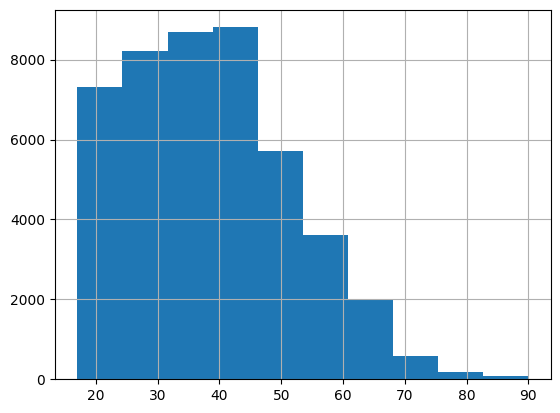

In [ ]:
df["age"].hist()
plt.show()

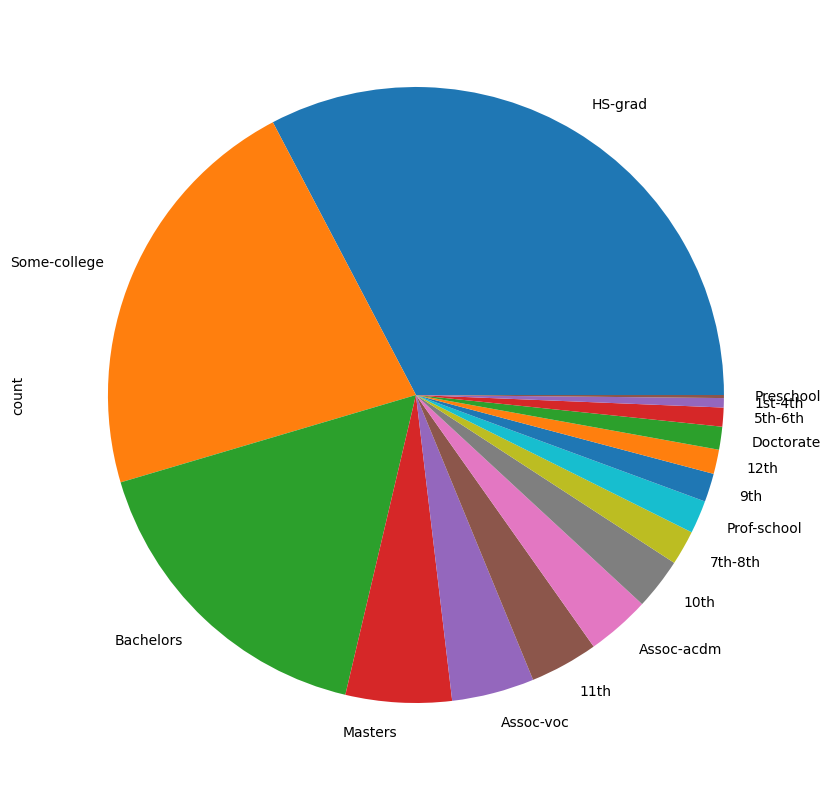

In [ ]:
# distribution of educwtion
%matplotlib inline
import matplotlib.pyplot as plt
df["education"].value_counts().plot.pie(figsize=(15,10))
plt.show()

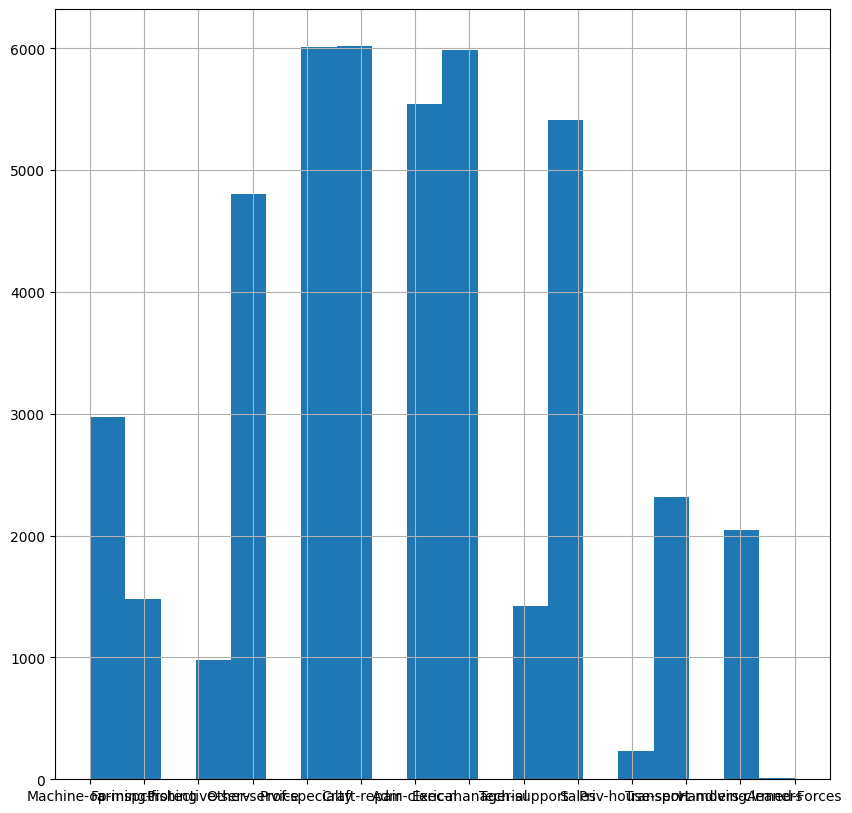

In [ ]:
#Distribution of work class
df["occupation"].hist(bins=20,figsize= (10,10))
plt.show()

In [ ]:
df.head(5)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


Task 1: Income Distribution Analysis

Dekho ki >50K aur <=50K earners ka ratio kya hai


Identify karo kon se factors (education, age, occupation) income ko sabse zyada affect karte hain


Mujhe ek clear recommendation do: "Agar kisi ko high income chahiye toh kya karna chahiye?"


📊 Income Distribution:
   Ratio (<=50K : >50K) = 3.18:1

   Percentage Breakdown:
income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64
HELLO  income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64


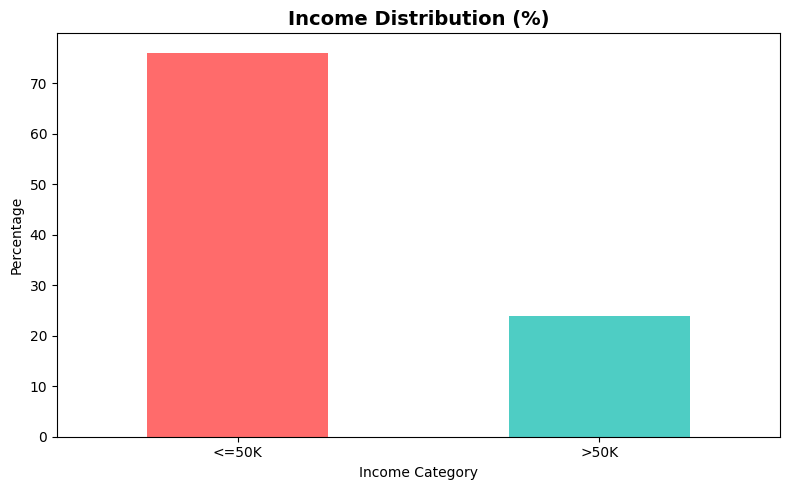

In [ ]:
income_counts = df["income"].value_counts()
income_ratio = income_counts.iloc[0] / income_counts.iloc[1]
income_percentage = df['income'].value_counts(normalize=True) * 100

print(f"\n Income Distribution:")
print(f"   Ratio (<=50K : >50K) = {income_ratio:.2f}:1")
print(f"\n   Percentage Breakdown:")
print(income_percentage)
print('HELLO ',df["income"].value_counts(normalize=True))
# Visualization
plt.figure(figsize=(8, 5))
income_percentage.plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
plt.title('Income Distribution (%)', fontsize=14, fontweight='bold')
plt.xlabel('Income Category')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()




In [ ]:
a=pd.crosstab(df["income"],df["education"],margins =True)
print(a)
              

education  10th  11th  12th  1st-4th  5th-6th  7th-8th  9th  Assoc-acdm  \
income                                                                    
<=50K      1302  1720   609      239      482      893  715        1188   
>50K         87    92    48        8       27       62   41         413   
All        1389  1812   657      247      509      955  756        1601   

education  Assoc-voc  Bachelors  Doctorate  HS-grad  Masters  Preschool  \
income                                                                    
<=50K           1539       4712        163    13281     1198         82   
>50K             522       3313        431     2503     1459          1   
All             2061       8025        594    15784     2657         83   

education  Prof-school  Some-college    All  
income                                       
<=50K              217          8815  37155  
>50K               617          2063  11687  
All                834         10878  48842  



FACTOR 1: AGE IMPACT
             mean  median        std
income                              
<=50K   36.872184    34.0  14.104118
>50K    44.275178    43.0  10.558983


<Figure size 1000x500 with 0 Axes>

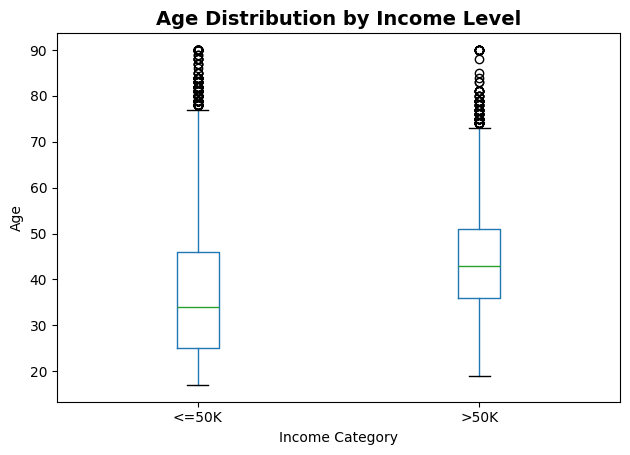


💡 Insight: High earners are on average 7.4 years older


In [ ]:
# 1. Age Analysis
print("\n" + "="*50)
print("FACTOR 1: AGE IMPACT")
print("="*50)

age_by_income = df.groupby("income")["age"].agg(['mean', 'median', 'std'])
print(age_by_income)

plt.figure(figsize=(10, 5))
df.boxplot(column='age', by='income', grid=False)
plt.suptitle('')
plt.title('Age Distribution by Income Level', fontsize=14, fontweight='bold')
plt.xlabel('Income Category')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

print(f"\n💡 Insight: High earners are on average {age_by_income.loc['>50K', 'mean'] - age_by_income.loc['<=50K', 'mean']:.1f} years older")


FACTOR 2: EDUCATION IMPACT

Percentage earning >50K by education level:
education
Prof-school     73.980815
Doctorate       72.558923
Masters         54.911554
Bachelors       41.283489
Assoc-acdm      25.796377
Assoc-voc       25.327511
Some-college    18.964883
HS-grad         15.857831
12th             7.305936
7th-8th          6.492147
10th             6.263499
9th              5.423280
5th-6th          5.304519
11th             5.077263
1st-4th          3.238866
Preschool        1.204819
Name: >50K, dtype: float64


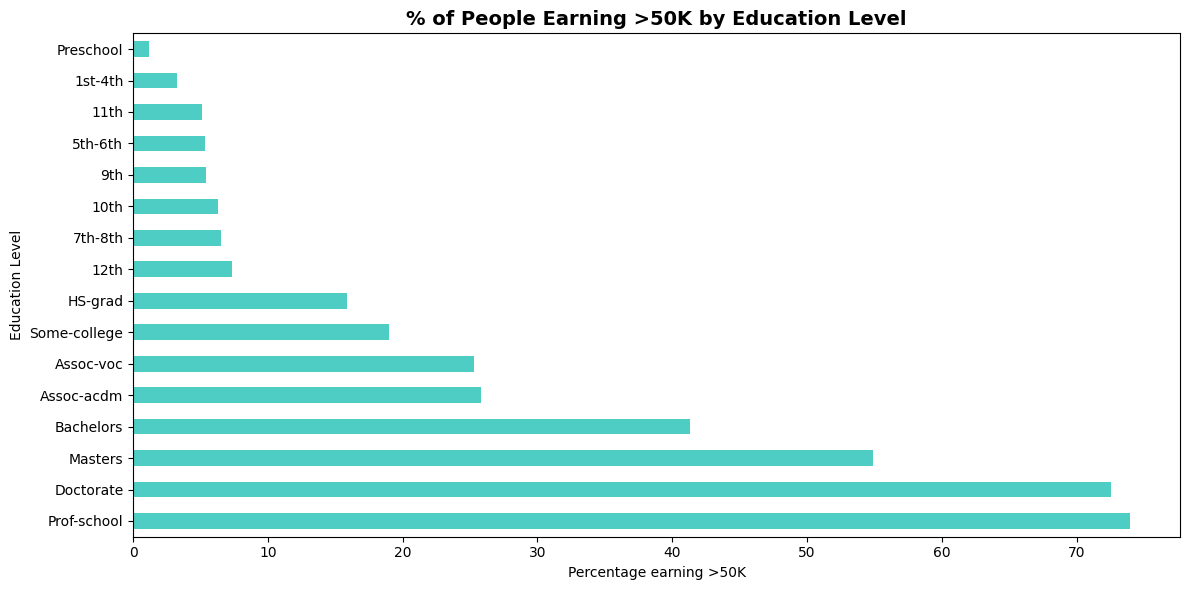


💡 Insight: Prof-school has highest chance (74.0%) of earning >50K


In [ ]:
# 2. Education Analysis
print("\n" + "="*50)
print("FACTOR 2: EDUCATION IMPACT")
print("="*50)

education_income = pd.crosstab(df['education'], df['income'], normalize='index') * 100
education_income = education_income.sort_values(by='>50K', ascending=False)
print("\nPercentage earning >50K by education level:")
print(education_income['>50K'])

plt.figure(figsize=(12, 6))
education_income['>50K'].plot(kind='barh', color='#4ECDC4')
plt.title('% of People Earning >50K by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Percentage earning >50K')
plt.ylabel('Education Level')
plt.tight_layout()
plt.show()

top_education = education_income['>50K'].idxmax()
print(f"\n💡 Insight: {top_education} has highest chance ({education_income.loc[top_education, '>50K']:.1f}%) of earning >50K")


FACTOR 3: OCCUPATION IMPACT

Top 10 occupations by % earning >50K:
occupation
Exec-managerial      47.781794
Prof-specialty       45.106935
Armed-Forces         33.333333
Protective-serv      31.332655
Tech-support         29.045643
Sales                26.798692
Craft-repair         22.627618
Transport-moving     20.424628
Adm-clerical         13.687400
Machine-op-inspct    12.309729
Name: >50K, dtype: float64


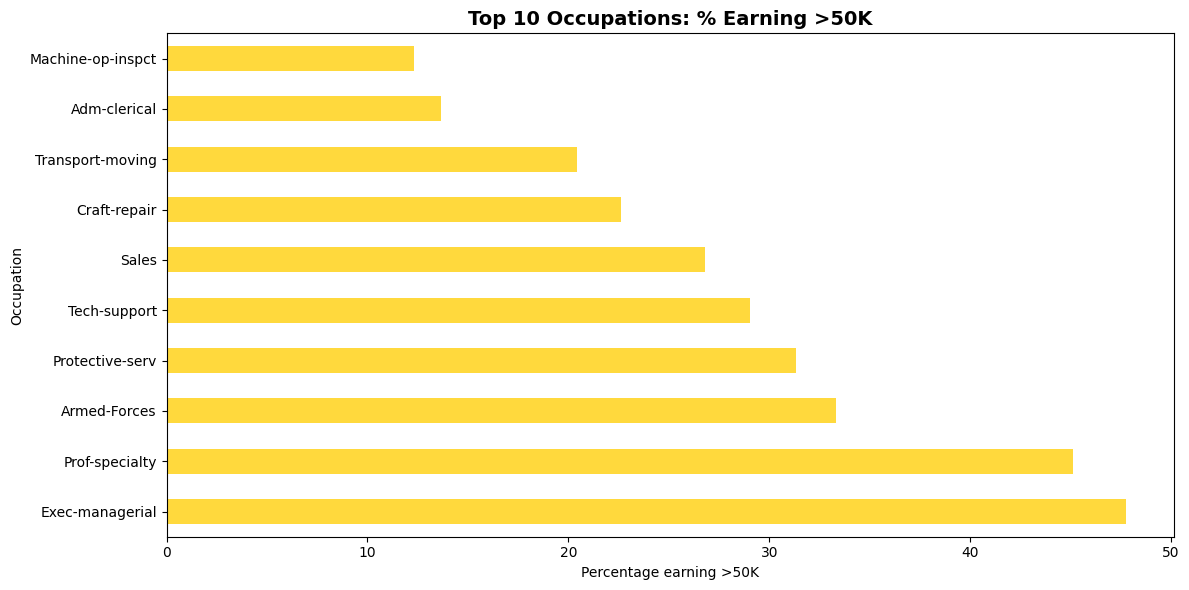


FACTOR 4: WORKING HOURS IMPACT
income
<=50K    38.840048
>50K     45.452896
Name: hours-per-week, dtype: float64

💡 Insight: High earners work 6.6 more hours per week on average


In [ ]:
# 3. Occupation Analysis
print("\n" + "="*50)
print("FACTOR 3: OCCUPATION IMPACT")
print("="*50)

occupation_income = pd.crosstab(df['occupation'], df['income'], normalize='index') * 100
occupation_income = occupation_income.sort_values(by='>50K', ascending=False)
print("\nTop 10 occupations by % earning >50K:")
print(occupation_income['>50K'].head(10))

plt.figure(figsize=(12, 6))
occupation_income['>50K'].head(10).plot(kind='barh', color='#FFD93D')
plt.title('Top 10 Occupations: % Earning >50K', fontsize=14, fontweight='bold')
plt.xlabel('Percentage earning >50K')
plt.ylabel('Occupation')
plt.tight_layout()
plt.show()

# 4. Hours per week analysis
print("\n" + "="*50)
print("FACTOR 4: WORKING HOURS IMPACT")
print("="*50)

hours_by_income = df.groupby("income")["hours-per-week"].mean()
print(hours_by_income)

print(f"\n💡 Insight: High earners work {hours_by_income['>50K'] - hours_by_income['<=50K']:.1f} more hours per week on average")



EDUCATION ROI ANALYSIS

Task 2: Education ROI Analysis

Education level aur income ka correlation nikalo


Batao ki kaunsi education level mein maximum ROI hai

Hours worked vs income - kya zyada ghante = zyada paisa?

In [ ]:
df.head(1)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K


##################################################
To find correlation between income and Education lvl
##################################################
The correlation between income and education is
income        <=50K  >50K
education                
10th           1302    87
11th           1720    92
12th            609    48
1st-4th         239     8
5th-6th         482    27
7th-8th         893    62
9th             715    41
Assoc-acdm     1188   413
Assoc-voc      1539   522
Bachelors      4712  3313
Doctorate       163   431
HS-grad       13281  2503
Masters        1198  1459
Preschool        82     1
Prof-school     217   617
Some-college   8815  2063
There is no deviation in chi square value ass the value is 0.0 this tells us
Education has absolutely no association with income .


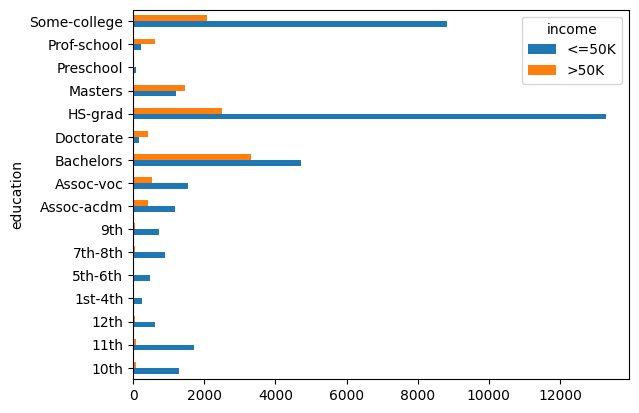

In [ ]:
print("#"*50)
print("To find correlation between income and Education lvl")
print("#"*50)
print("Both are catgorical values so we cannot use correlation coefficient rather we are going to use chi square method")
print("The correlation between income and education is")
corr_between_edu_and_income = pd.crosstab(df["education"],df["income"])
print(corr_between_edu_and_income)
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(corr_between_edu_and_income)

p
print("There is no deviation in chi square value ass the value is 0.0 this tells us")
print('Education has absolutely no association with income .')
corr_between_edu_and_income.plot(kind = "barh")
plt.show()





In [ ]:
df.head(1)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K


income     <=50K  >50K
hours_bin             
0–20        4152   301
21–40      24393  5644
41–60       7533  5143
60+         1077   599


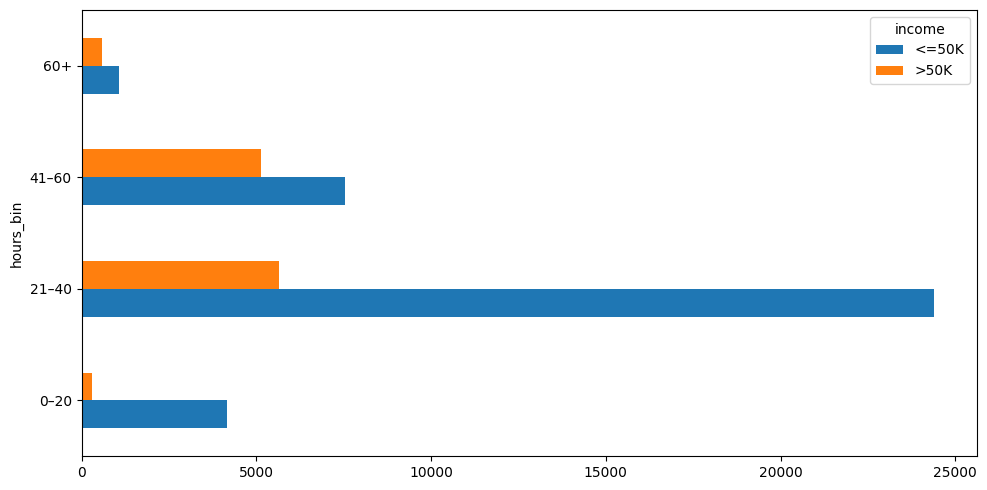

As we cann see there is no relation between more working hours and income There are people with less than 50k salary working more than people having salary more than 50k


In [ ]:
bins = [0, 20, 40, 60, 100]
labels = ['0–20', '21–40', '41–60', '60+']

df['hours_bin'] = pd.cut(df['hours-per-week'], bins=bins, labels=labels)
print(pd.crosstab(df['hours_bin'], df['income']))

pd.crosstab(df['hours_bin'], df['income']).plot(
    kind='barh',
    figsize=(10, 5)
)
plt.tight_layout()
plt.show()


print("As we cann see there is no relation between more working hours and income There are people with less than 50k salary working more than people having salary more than 50k")

Task 3: Gender Pay Gap Report

Male vs Female income comparison (detailed breakdown chahiye)

Occupation-wise gender distribution dekho

Kya gender pay gap exist karta hai? Agar haan toh kitna?


In [ ]:
df.head(1)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K


income      <=50K       >50K
gender                      
Female  29.529913   3.621883
Male    46.541911  20.306294


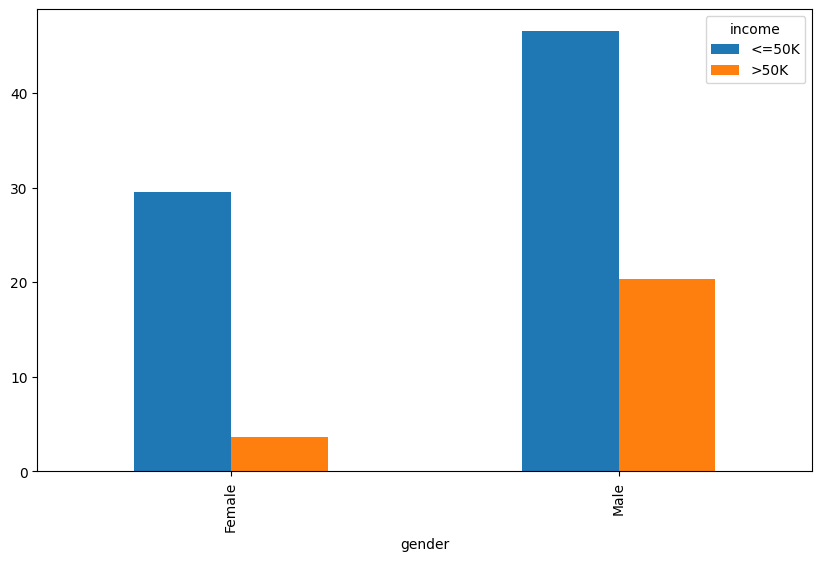

In [ ]:
male_vs_female_income_comparison = pd.crosstab(df["gender"],df['income'],normalize= True)*100
print(male_vs_female_income_comparison)
male_vs_female_income_comparison.plot(kind = "bar",figsize=(10,6))
plt.tight_layout
plt.show()
print("We can see tha")

In [42]:
df["gender"].value_counts()

gender
Male      32650
Female    16192
Name: count, dtype: int64

income                  <=50K      >50K
education    gender                    
10th         Female  0.009275  0.000082
             Male    0.017383  0.001699
11th         Female  0.013083  0.000225
             Male    0.022133  0.001658
12th         Female  0.004238  0.000082
             Male    0.008231  0.000901
1st-4th      Female  0.001249  0.000000
             Male    0.003644  0.000164
5th-6th      Female  0.002518  0.000082
             Male    0.007350  0.000471
7th-8th      Female  0.004873  0.000020
             Male    0.013411  0.001249
9th          Female  0.004402  0.000102
             Male    0.010237  0.000737
Assoc-acdm   Female  0.011077  0.001761
             Male    0.013247  0.006695
Assoc-voc    Female  0.013124  0.001904
             Male    0.018386  0.008783
Bachelors    Female  0.040048  0.010667
             Male    0.056427  0.057164
Doctorate    Female  0.001003  0.001310
             Male    0.002334  0.007514
HS-grad      Female  0.097600  0.006756


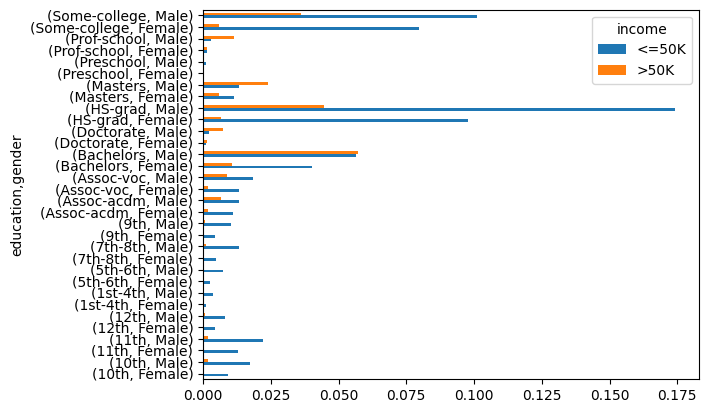

 the gender pay gap is not huge we are seeing this because in our dataset there are less females than males if we see by percentage you can see there is not much vast difference


In [44]:
occupation_wise_gender_distribution = pd.crosstab(
    index=[df["education"], df["gender"]],
    columns=df["income"],
    normalize= True
)
print(occupation_wise_gender_distribution)
occupation_wise_gender_distribution.plot(kind = "barh")
plt.tight_layout
plt.show()

print(" the gender pay gap is not huge we are seeing this because in our dataset there are less females than males if we see by percentage you can see there is not much vast difference")


Secondary Tasks (Medium Priority):

Task 4: Occupation Profiling


Top 5 highest paying occupations identify karo


Har occupation mein average age, education, hours-per-week batao

Recommendation: Freshers ko kaunse field mein jaana chahiye?

In [57]:
df.head(20)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,NaN,227026,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


In [56]:
df.groupby("occupation")["income"].max()

occupation
Adm-clerical         >50K
Armed-Forces         >50K
Craft-repair         >50K
Exec-managerial      >50K
Farming-fishing      >50K
Handlers-cleaners    >50K
Machine-op-inspct    >50K
Other-service        >50K
Priv-house-serv      >50K
Prof-specialty       >50K
Protective-serv      >50K
Sales                >50K
Tech-support         >50K
Transport-moving     >50K
Name: income, dtype: object

To avoid multi-index = df.groupby(['col1', 'col2'], as_index=False).sum()


In [ ]:
every_occupation_avg_age_education_work_per_week = df.groupby("occupation").agg({
    "age": "mean",
    "education": lambda x: x.mode()[0],  # Most common education # mode funciton ek series return krta hai [o] use krne se pehli index wala deta hai
    "hours-per-week": "mean"
})
print(every_occupation_avg_age_education_work_per_week)

                         age     education  hours-per-week
occupation                                                
Adm-clerical       37.193014       HS-grad       37.708073
Armed-Forces       31.466667       HS-grad       41.600000
Craft-repair       39.008671       HS-grad       42.269306
Exec-managerial    42.198488     Bachelors       44.975353
Farming-fishing    41.280537       HS-grad       46.817450
Handlers-cleaners  32.654440       HS-grad       37.911197
Machine-op-inspct  37.736267       HS-grad       40.778623
Other-service      35.108674       HS-grad       34.751980
Priv-house-serv    43.400826       HS-grad       33.024793
Prof-specialty     40.559786     Bachelors       42.282890
Protective-serv    38.899288       HS-grad       42.789420
Sales              37.408612       HS-grad       40.749273
Tech-support       37.150069  Some-college       39.720609
Transport-moving   40.651380       HS-grad       44.727389
